In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [36]:
basf_df = pd.read_csv("BASF1923.csv", parse_dates=["Date"])
basf_df.set_index("Date", inplace=True)

In [41]:
# defining variables
trading_days =250

Overall drift (mu): 0.0070
Overall volatility (sigma): 0.3037
Year 2019:drift (mu)=0.1063, volatility (sigma)=0.2210
Year 2020:drift (mu)=0.0228, volatility (sigma)=0.4241
Year 2021:drift (mu)=0.0014, volatility (sigma)=0.2032
Year 2022:drift (mu)=-0.2108, volatility (sigma)=0.3513
Year 2023:drift (mu)=0.1213, volatility (sigma)=0.2590


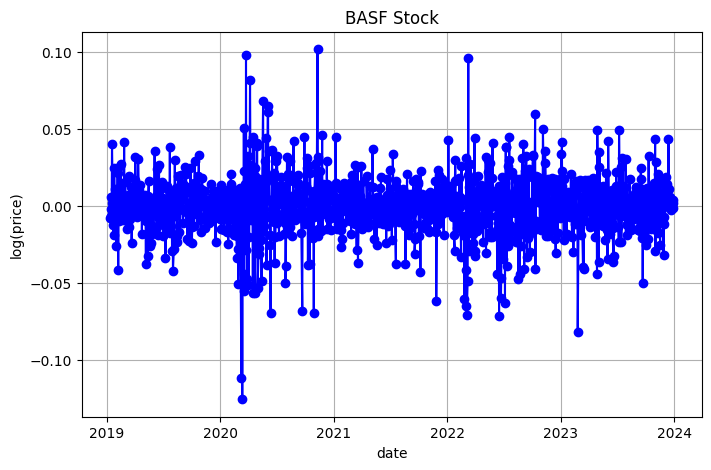

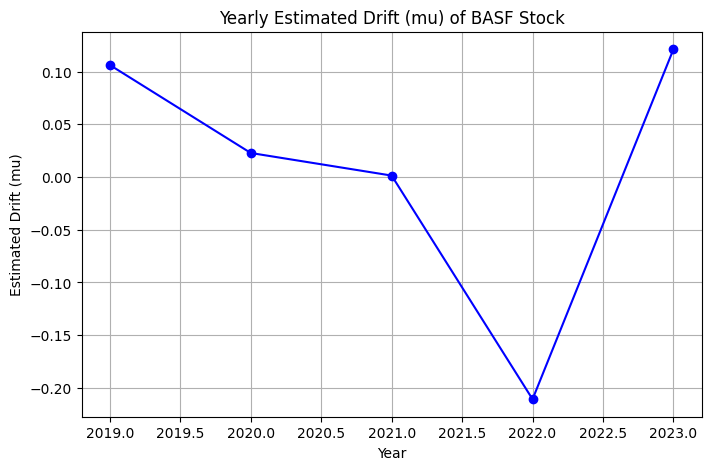

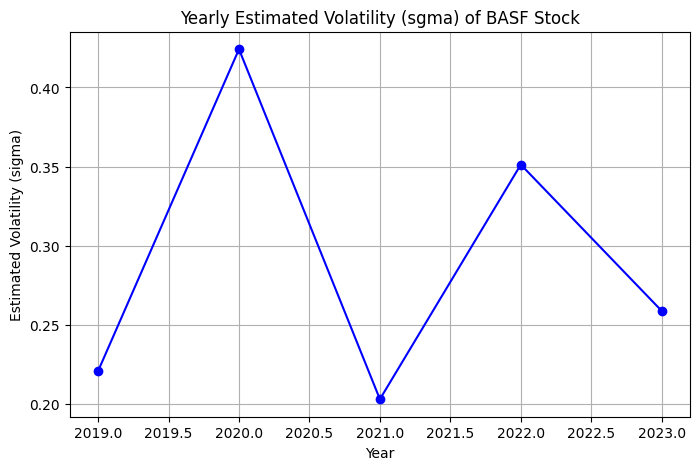

In [47]:
# Calculate daily log returns
basf_df['lg_r'] = np.log(basf_df['BASFClose'] / basf_df['BASFClose'].shift(1))
basf_df.dropna(inplace=True)

# Estimate drift and volatility for the whole period
mu_total = basf_df['lg_r'].mean() * trading_days
sigma_total = basf_df['lg_r'].std() * np.sqrt(trading_days)

print(f"Overall drift (mu): {mu_total:.4f}")
print(f"Overall volatility (sigma): {sigma_total:.4f}")

years = []
mu_years = []
sigma_years = []

# Estimate drift and volatility for each year separately
for year in basf_df.index.year.unique():
    df_year = basf_df[basf_df.index.year == year]
    mu_year = df_year['lg_r'].mean() * trading_days
    sigma_year = df_year['lg_r'].std() * np.sqrt(trading_days)
    years.append(year)
    mu_years.append(mu_year)
    sigma_years.append(sigma_year)
    print(f"Year {year}:drift (mu)={mu_year:.4f}, volatility (sigma)={sigma_year:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(basf_df.index, basf_df["lg_r"], marker='o', linestyle='-', color='blue')
plt.xlabel('date')
plt.ylabel('log(price)')
plt.title('BASF Stock')
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(years, mu_years, marker='o', linestyle='-', color='blue')
plt.xlabel('Year')
plt.ylabel('Estimated Drift (mu)')
plt.title('Yearly Estimated Drift (mu) of BASF Stock')
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(years, sigma_years, marker='o', linestyle='-', color='blue')
plt.xlabel('Year')
plt.ylabel('Estimated Volatility (sigma)')
plt.title('Yearly Estimated Volatility (sgma) of BASF Stock')
plt.grid(True)
plt.show()

### Description

It can be observed that the drift is decreasing over the period and increased in the last period. This relates to negative price changes during the periods. Only in 2024 they returned to a positive trend.
The volatility is showing great spikes between the years 2019 to 2022. However, the volatility is decreasing after 2021 which shows less drastic market movements. 
Overall the price of BASF should show a negative trend with great spikes in positive and negative price movements, whereby recovery in the last year.